In [10]:
import pandas as pd

df = pd.read_csv("../data/ucf101_subset/test.csv")

In [11]:
display(df.head())
display(df.info())
display(df.describe())

,clip_name,clip_path,label,frame_count,duration_sec,fps,width,height,resolution
0,v_Swing_g21_c02,/test/Swing/v_Swing_g21_c02.avi,Swing,168,6.72,25.0,320,240,320x240
1,v_Swing_g21_c06,/test/Swing/v_Swing_g21_c06.avi,Swing,201,8.04,25.0,320,240,320x240
2,v_Swing_g20_c05,/test/Swing/v_Swing_g20_c05.avi,Swing,151,6.04,25.0,320,240,320x240
3,v_Swing_g04_c03,/test/Swing/v_Swing_g04_c03.avi,Swing,168,6.72,25.0,320,240,320x240
4,v_Swing_g19_c03,/test/Swing/v_Swing_g19_c03.avi,Swing,276,11.04,25.0,320,240,320x240


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1723 entries, 0 to 1722
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   clip_name     1723 non-null   object 
 1   clip_path     1723 non-null   object 
 2   label         1723 non-null   object 
 3   frame_count   1723 non-null   int64  
 4   duration_sec  1723 non-null   float64
 5   fps           1723 non-null   float64
 6   width         1723 non-null   int64  
 7   height        1723 non-null   int64  
 8   resolution    1723 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 121.3+ KB


None

,frame_count,duration_sec,fps,width,height
count,1723.000000,1723.000000,1723.000000,1723.000000,1723.000000
mean,185.580383,7.173359,25.928785,320.046431,239.991875
std,94.856912,3.652996,1.937905,1.927291,0.337276
min,32.000000,1.067733,25.000000,320.000000,226.000000
25%,115.000000,4.440000,25.000000,320.000000,240.000000
50%,167.000000,6.520000,25.000000,320.000000,240.000000
75%,243.500000,9.520000,25.000000,320.000000,240.000000
max,833.000000,33.320000,29.970030,400.000000,240.000000


In [ ]:
total_frames = df["frame_count"].sum()
total_duration_hours = df["duration_sec"].sum() / 3600

print(f"\nTotal videos: {len(df)}")
print(f"Total frames to process: {total_frames}")
print(f"Total duration (hours): {total_duration_hours:.2f}")

res_summary = (
    df["resolution"].value_counts().rename_axis("resolution").reset_index(name="count")
)
res_summary["proportion"] = res_summary["count"] / res_summary["count"].sum()

print(res_summary)


Total videos: 1723
Total frames to process: 319755
Total duration (hours): 3.43
  resolution  count  proportion
0    320x240   1722     0.99942
1    400x226      1     0.00058


In [ ]:
df["label"].value_counts()

label
Basketball           34
ShavingBeard         21
PlayingDhol          21
BoxingPunchingBag    21
TennisSwing          21
                     ..
PullUps              13
PushUps              13
TaiChi               13
PlayingViolin        13
Skijet               13
Name: count, Length: 101, dtype: int64

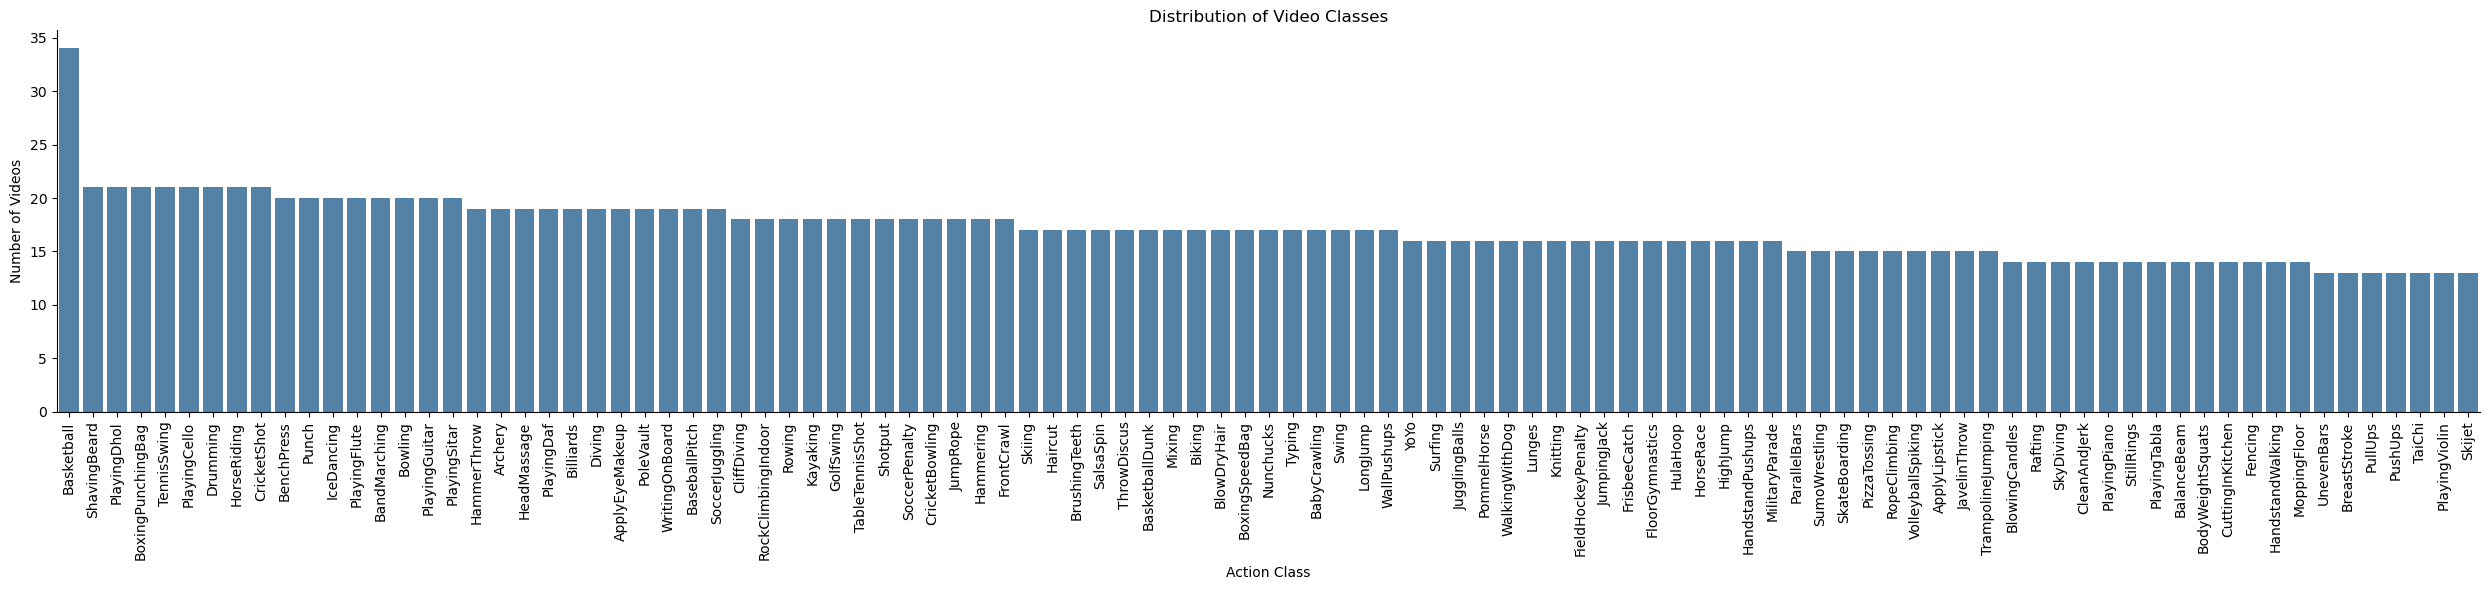

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(25, 6))
sns.countplot(
    x="label", data=df, order=df["label"].value_counts().index, color="steelblue", ax=ax
)

ax.set_title("Distribution of Video Classes")
ax.set_xlabel("Action Class")
ax.set_ylabel("Number of Videos")
ax.tick_params(axis="x", rotation=90)
sns.despine()
plt.tight_layout()


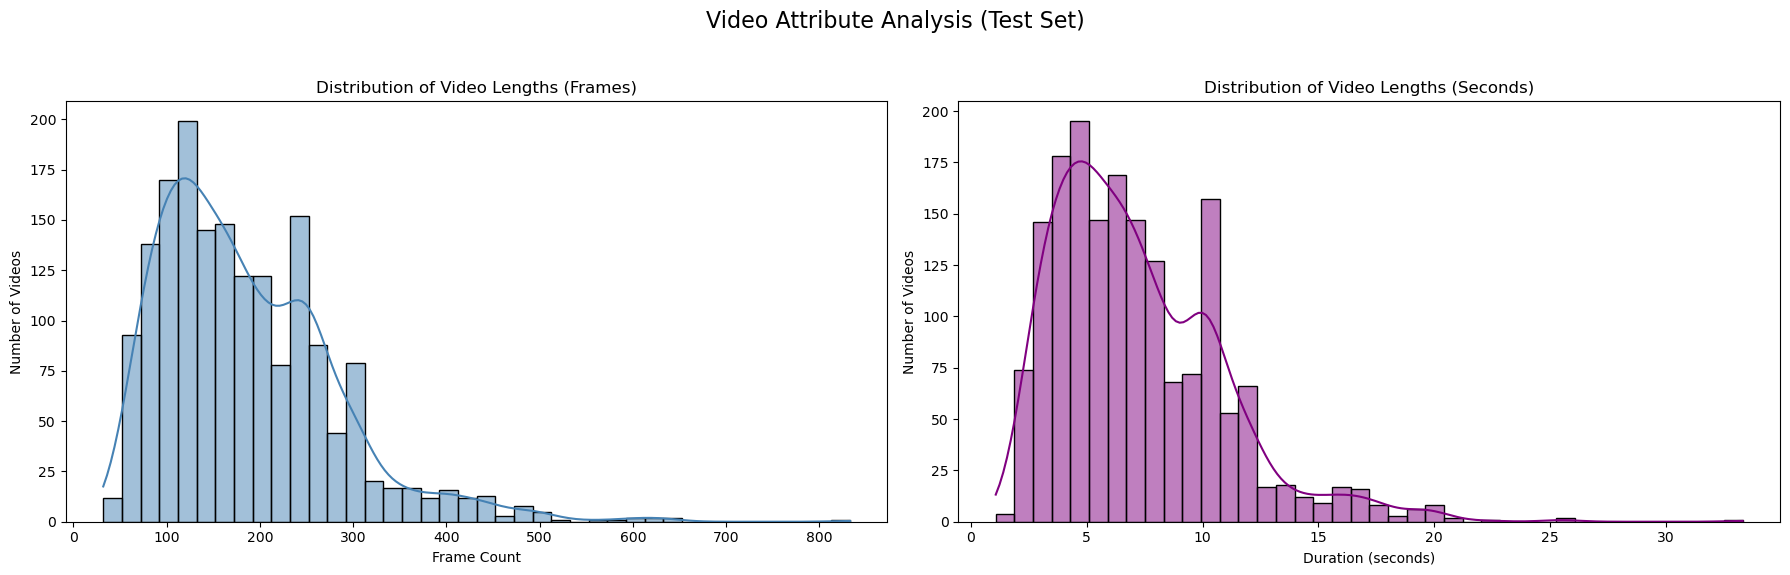

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Video Attribute Analysis (Test Set)", fontsize=16)

# Frame Count Histogram
sns.histplot(df["frame_count"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Video Lengths (Frames)")
axes[0].set_xlabel("Frame Count")
axes[0].set_ylabel("Number of Videos")

# Duration Histogram
sns.histplot(df["duration_sec"], bins=40, kde=True, ax=axes[1], color="purple")
axes[1].set_title("Distribution of Video Lengths (Seconds)")
axes[1].set_xlabel("Duration (seconds)")
axes[1].set_ylabel("Number of Videos")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

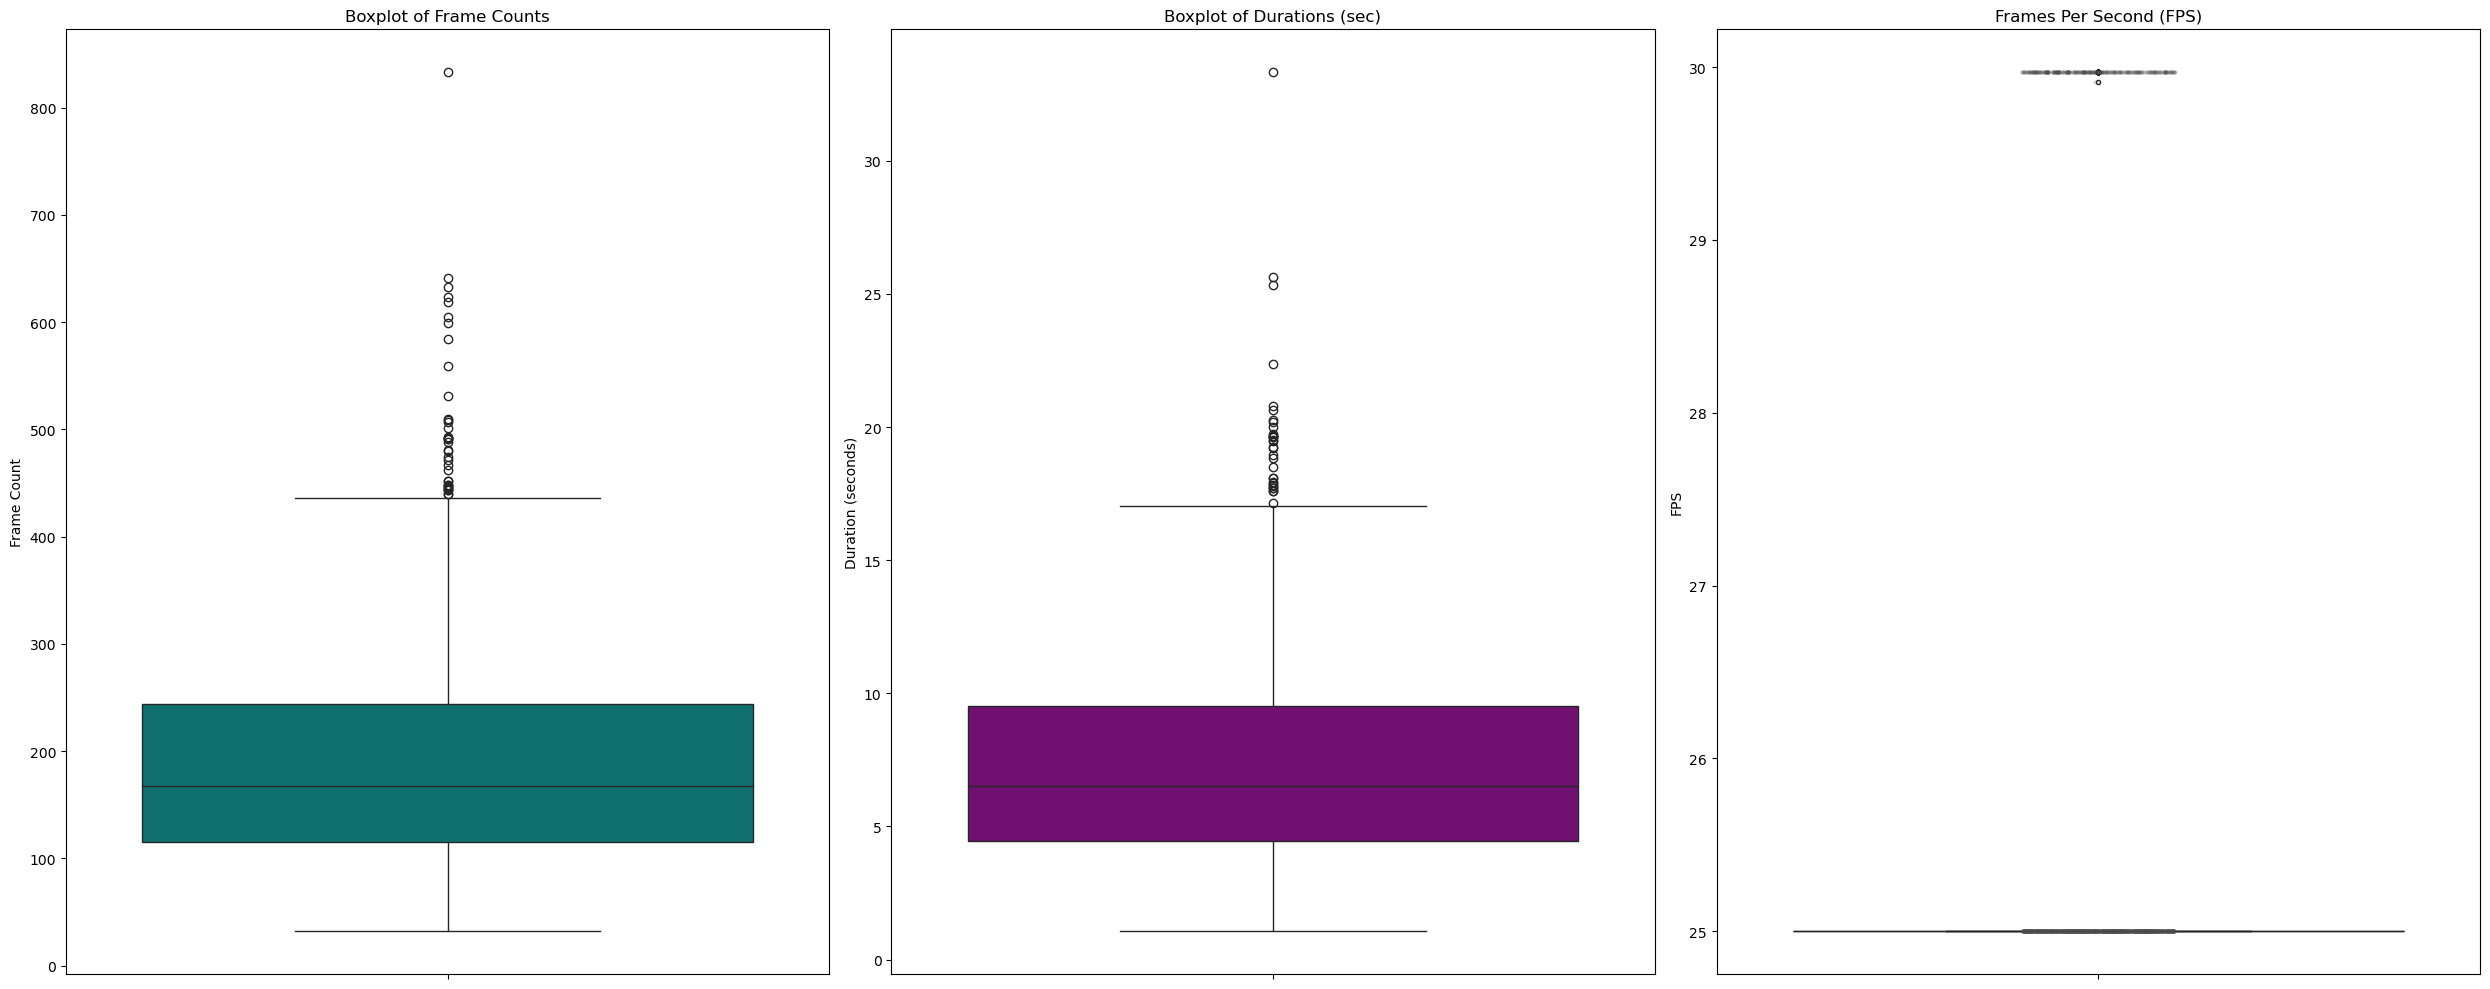

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

sns.boxplot(y=df["frame_count"], ax=axes[0], color="teal")
axes[0].set_title("Boxplot of Frame Counts")
axes[0].set_ylabel("Frame Count")

sns.boxplot(y=df["duration_sec"], ax=axes[1], color="purple")
axes[1].set_title("Boxplot of Durations (sec)")
axes[1].set_ylabel("Duration (seconds)")

sns.boxplot(y=df["fps"], ax=axes[2], color="green", fliersize=3)
sns.stripplot(y=df["fps"], ax=axes[2], color=".3", size=3, alpha=0.2)
axes[2].set_title("Frames Per Second (FPS)")
axes[2].set_ylabel("FPS")

plt.tight_layout()
plt.show()